In [11]:
import pandas as pd
import numpy as np
import random, time, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
random.seed(42)
np.random.seed(42)

In [2]:
# ---------- User-tweakable settings (safe for 8GB) ----------
DATA_PATH = "online_retail_II.xlsx"   # change if needed
SAMPLE_LIMIT = 3000                   # number of transactions to sample
TOP_ITEMS = 300                       # keep top-N frequent items before apriori
MIN_SUPPORT = 0.004                   # apriori support threshold
MIN_CONF = 0.30                       # rule confidence threshold
MAX_LEN = 2                           # max itemset length for apriori
N_FOLDS = 5                           # StratifiedKFold folds
N_TRIALS = 20                         # Optuna trials (20 is conservative)
RANDOM_STATE = 42

start_time = time.time()
print("Loading data...")
# ---------- Load dataset ----------
if DATA_PATH.endswith(('.xls', '.xlsx')):
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

Loading data...


In [23]:
df.shape

(417534, 8)

In [24]:
df.isnull().sum()

invoice        0
stockcode      0
description    0
quantity       0
invoicedate    0
price          0
customer_id    0
country        0
dtype: int64

In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.dropna(subset=['customer_id', 'description'], inplace=True)
df['description'] = df['description'].str.strip().str.lower()
print(f"✅ Data Loaded: {len(df)} rows")

✅ Data Loaded: 417534 rows


In [14]:
# ====================== 2. Create Transactions ======================
grouped = df.groupby(['customer_id', 'invoice'])['description'].apply(list)
transactions = grouped.values.tolist()

transactions = random.sample(transactions, min(3000, len(transactions)))
print(f"✅ Transactions prepared: {len(transactions)}")

✅ Transactions prepared: 3000


In [15]:
# ====================== 3. Apriori Frequent Itemsets ======================
print("⚙️ Running Apriori (memory optimized)...")
te = TransactionEncoder()
te_ary = te.fit_transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

item_freq = df_trans.sum().sort_values(ascending=False)
top_items = item_freq.head(300).index.tolist()
df_trans = df_trans[top_items]

frequent_items = apriori(df_trans, min_support=0.004, use_colnames=True, max_len=2)
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.3)
rules = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)
print(f"✅ Generated {len(frequent_items)} frequent itemsets & {len(rules)} rules")


⚙️ Running Apriori (memory optimized)...
✅ Generated 1671 frequent itemsets & 628 rules


In [16]:
# ====================== 4. Build Hybrid Feature Matrix (Apriori-based) ======================
itemsets = [set(x) for x in frequent_items['itemsets']]
X, y = [], []
for tx in transactions:
    tx_set = set(tx)
    features = [int(itemset.issubset(tx_set)) for itemset in itemsets]
    X.append(features)
    y.append(int(any(itemset.issubset(tx_set) for itemset in itemsets)))

X, y = np.array(X), np.array(y)
print(f"✅ Feature Matrix: {X.shape}, Label Balance: {np.bincount(y)}")

✅ Feature Matrix: (3000, 1671), Label Balance: [ 506 2494]


In [17]:
# ====================== 5. Balance Dataset ======================
print("⚖️ Balancing with SMOTE...")
sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X, y)
print(f"✅ After Balancing: {np.bincount(y_bal)}")


⚖️ Balancing with SMOTE...
✅ After Balancing: [2494 2494]


In [18]:
# ====================== 6. Prepare Hybrid Models ======================
models = {
    "Hybrid_Apriori_XGBoost": XGBClassifier(max_depth=5, learning_rate=0.15, n_estimators=120,
                                            subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                                            random_state=42, n_jobs=-1, eval_metric='logloss'),
    "Hybrid_Apriori_RandomForest": RandomForestClassifier(n_estimators=120, random_state=42, n_jobs=-1),
    "Hybrid_Apriori_DecisionTree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Hybrid_Apriori_LogisticRegression": LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42)
}


In [19]:

# ====================== 7. Stratified K-Fold Cross Validation ======================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for model_name, model in models.items():
    print(f"\n🤖 Training Hybrid Model: {model_name}")
    acc, prec, rec, f1s, aucs = [], [], [], [], []
    fold = 1

    for train_idx, test_idx in skf.split(X_bal, y_bal):
        X_train, X_test = X_bal[train_idx], X_bal[test_idx]
        y_train, y_test = y_bal[train_idx], y_bal[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            aucs.append(auc(fpr, tpr))
        else:
            aucs.append(0)

        acc.append(accuracy_score(y_test, y_pred))
        prec.append(precision_score(y_test, y_pred))
        rec.append(recall_score(y_test, y_pred))
        f1s.append(f1_score(y_test, y_pred))

        print(f"Fold {fold}: Accuracy={acc[-1]*100:.2f}% | F1={f1s[-1]*100:.2f}%")
        fold += 1

    results[model_name] = {
        'Accuracy': np.mean(acc),
        'Precision': np.mean(prec),
        'Recall': np.mean(rec),
        'F1': np.mean(f1s),
        'AUC': np.mean(aucs)
    }



🤖 Training Hybrid Model: Hybrid_Apriori_XGBoost
Fold 1: Accuracy=90.88% | F1=89.97%
Fold 2: Accuracy=88.38% | F1=86.85%
Fold 3: Accuracy=90.98% | F1=90.09%
Fold 4: Accuracy=89.27% | F1=87.96%
Fold 5: Accuracy=90.57% | F1=89.60%

🤖 Training Hybrid Model: Hybrid_Apriori_RandomForest
Fold 1: Accuracy=98.10% | F1=98.06%
Fold 2: Accuracy=96.79% | F1=96.69%
Fold 3: Accuracy=97.70% | F1=97.64%
Fold 4: Accuracy=98.09% | F1=98.06%
Fold 5: Accuracy=97.99% | F1=97.96%

🤖 Training Hybrid Model: Hybrid_Apriori_DecisionTree
Fold 1: Accuracy=71.14% | F1=59.44%
Fold 2: Accuracy=70.54% | F1=58.24%
Fold 3: Accuracy=71.84% | F1=60.81%
Fold 4: Accuracy=71.11% | F1=59.32%
Fold 5: Accuracy=71.61% | F1=60.42%

🤖 Training Hybrid Model: Hybrid_Apriori_LogisticRegression
Fold 1: Accuracy=94.49% | F1=94.17%
Fold 2: Accuracy=92.59% | F1=91.99%
Fold 3: Accuracy=94.59% | F1=94.28%
Fold 4: Accuracy=93.28% | F1=92.79%
Fold 5: Accuracy=93.78% | F1=93.38%



📊 Hybrid Model Performance Summary:
                                    Accuracy  Precision    Recall        F1  \
Hybrid_Apriori_RandomForest        0.977347        1.0  0.954694  0.976796   
Hybrid_Apriori_LogisticRegression  0.937449        1.0  0.874896  0.933205   
Hybrid_Apriori_XGBoost             0.900160        1.0  0.800315  0.888938   
Hybrid_Apriori_DecisionTree        0.712510        1.0  0.425019  0.596452   

                                        AUC  
Hybrid_Apriori_RandomForest        0.999599  
Hybrid_Apriori_LogisticRegression  1.000000  
Hybrid_Apriori_XGBoost             0.967919  
Hybrid_Apriori_DecisionTree        0.712509  


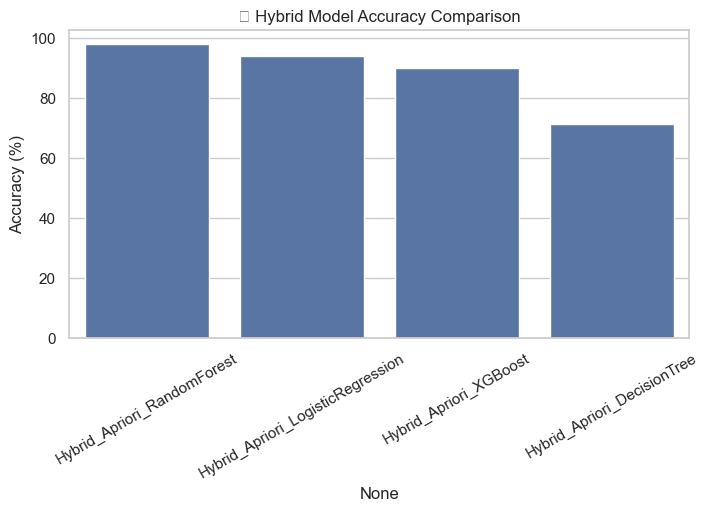

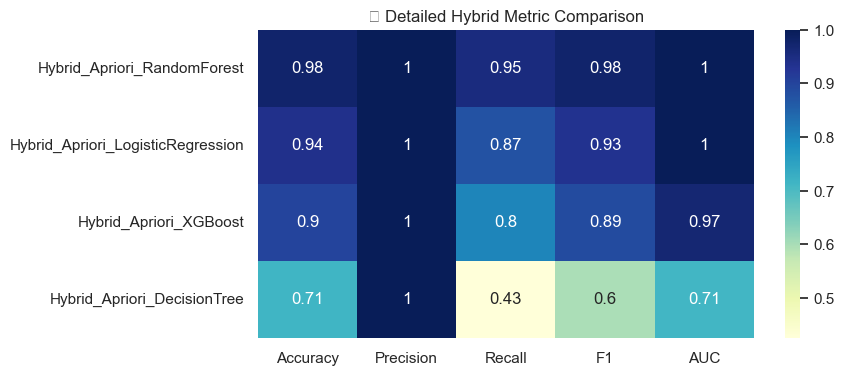

In [20]:
# ====================== 8. Results Summary ======================
results_df = pd.DataFrame(results).T.sort_values(by='Accuracy', ascending=False)
print("\n📊 Hybrid Model Performance Summary:\n", results_df)

# ====================== 9. Visualization ======================
plt.figure(figsize=(8, 4))
sns.barplot(x=results_df.index, y=results_df['Accuracy'] * 100)
plt.title("📈 Hybrid Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']], annot=True, cmap='YlGnBu')
plt.title("🔥 Detailed Hybrid Metric Comparison")
plt.show()

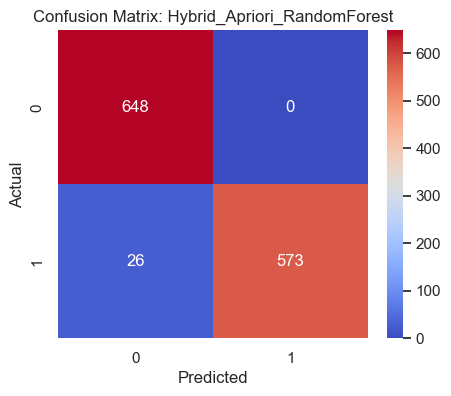


🧾 Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       648
           1       1.00      0.96      0.98       599

    accuracy                           0.98      1247
   macro avg       0.98      0.98      0.98      1247
weighted avg       0.98      0.98      0.98      1247



In [21]:
# ====================== 10. Confusion Matrix for Best Hybrid Model ======================
best_model_name = results_df.index[0]
best_model = models[best_model_name]

X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.25, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n🧾 Classification Report:\n", classification_report(y_test, y_pred))

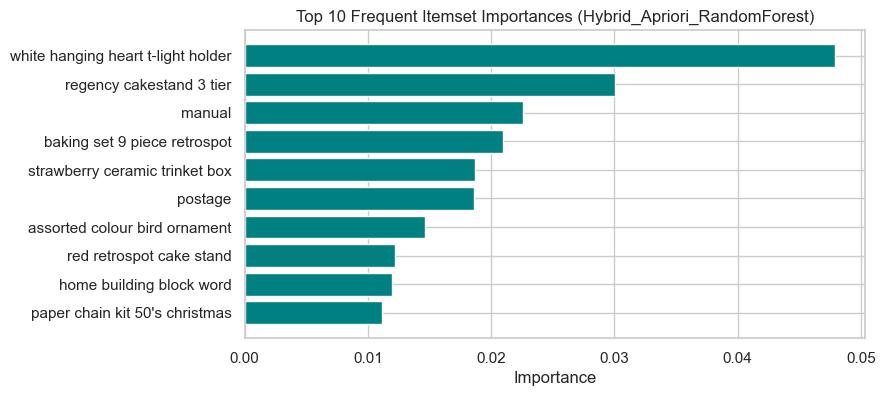


✅ All Hybrid models evaluated successfully.


In [22]:

# ====================== 11. Feature Importances (For all models supporting it) ======================
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    top_idx = np.argsort(importances)[-10:]
    plt.figure(figsize=(8, 4))
    plt.barh(range(10), importances[top_idx], color='teal')
    plt.yticks(range(10), [', '.join(list(frequent_items.iloc[i]['itemsets'])) for i in top_idx])
    plt.xlabel("Importance")
    plt.title(f"Top 10 Frequent Itemset Importances ({best_model_name})")
    plt.show()

print("\n✅ All Hybrid models evaluated successfully.")

### 1️⃣ ROC Curves (Comparison Across Models)

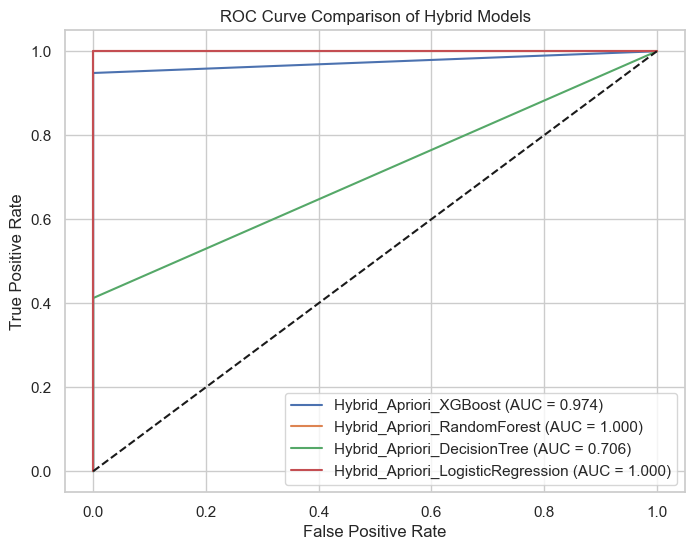

In [25]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve Comparison of Hybrid Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


### 2️⃣ Precision–Recall Curve

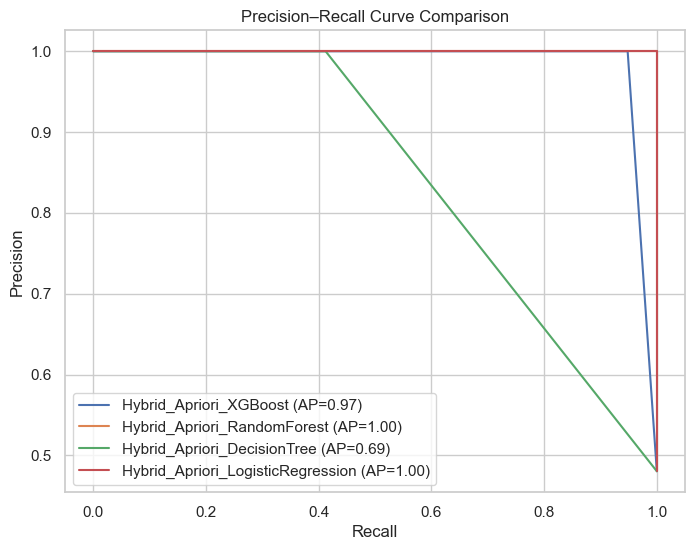

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.2f})')

plt.title("Precision–Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


### 4️⃣ Confusion Matrix (as Heatmap per Model)

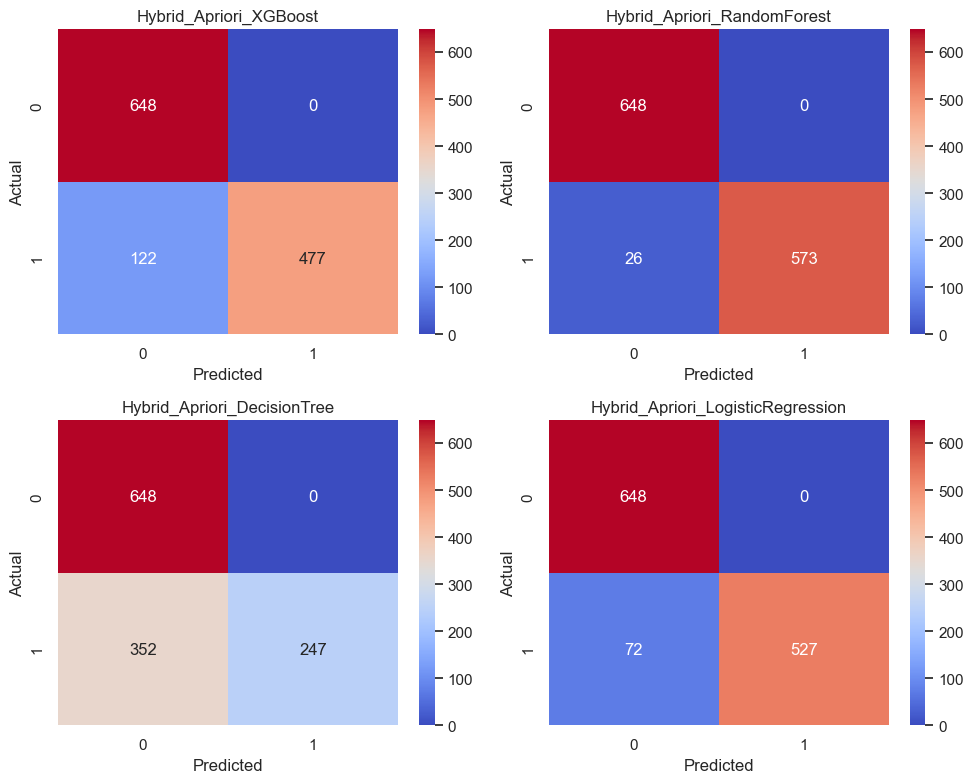

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', ax=axes[idx])
    axes[idx].set_title(f"{name}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 3️⃣ Feature Importance (Top 20 Itemsets)

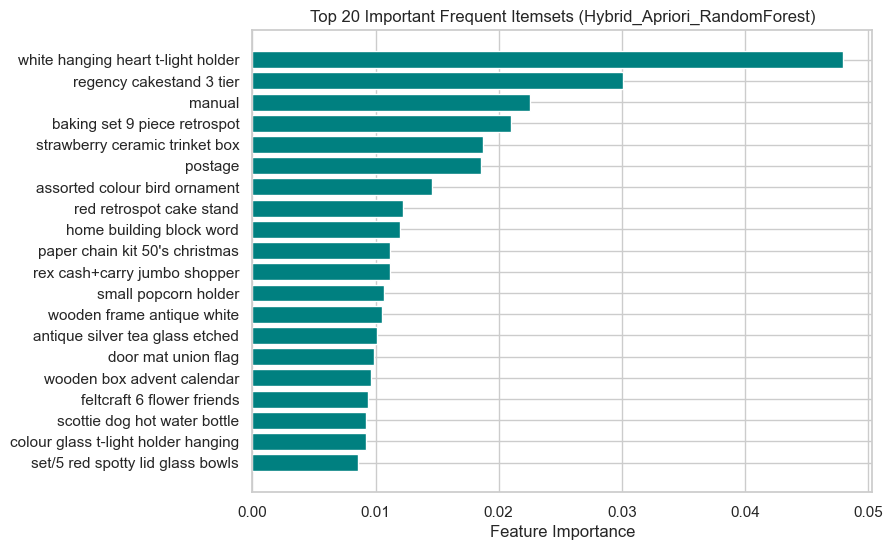

In [28]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    idx = np.argsort(importances)[-20:]
    labels = [', '.join(list(frequent_items.iloc[i]['itemsets'])) for i in idx]
    plt.figure(figsize=(8,6))
    plt.barh(range(len(idx)), importances[idx], color='teal')
    plt.yticks(range(len(idx)), labels)
    plt.title(f"Top 20 Important Frequent Itemsets ({best_model_name})")
    plt.xlabel("Feature Importance")
    plt.show()


### 5️⃣ Correlation Heatmap of Frequent Itemsets

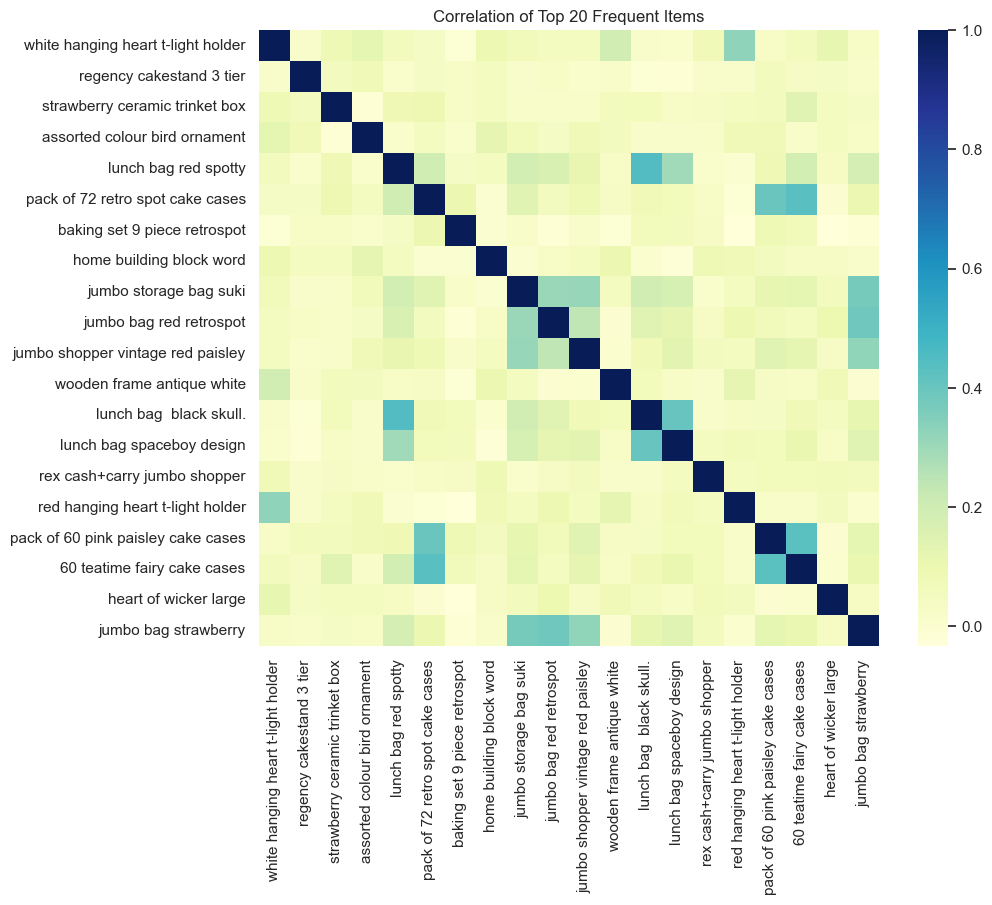

In [29]:
plt.figure(figsize=(10,8))
corr = df_trans[top_items[:20]].corr()
sns.heatmap(corr, cmap="YlGnBu")
plt.title("Correlation of Top 20 Frequent Items")
plt.show()


### 6️⃣ Model Metric Radar Chart

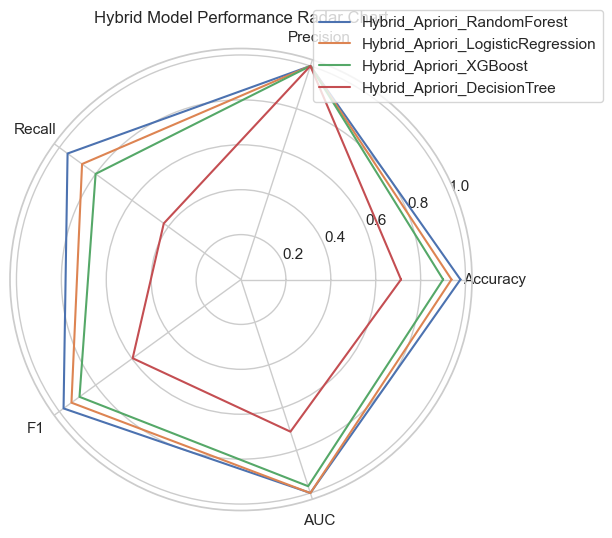

In [30]:
from math import pi

metrics = ['Accuracy','Precision','Recall','F1','AUC']
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8,6))
for name, row in results_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    plt.polar(angles, values, label=name)
    
plt.xticks(angles[:-1], metrics)
plt.title("Hybrid Model Performance Radar Chart")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


### 7️⃣ Training Time Comparison (if recorded)

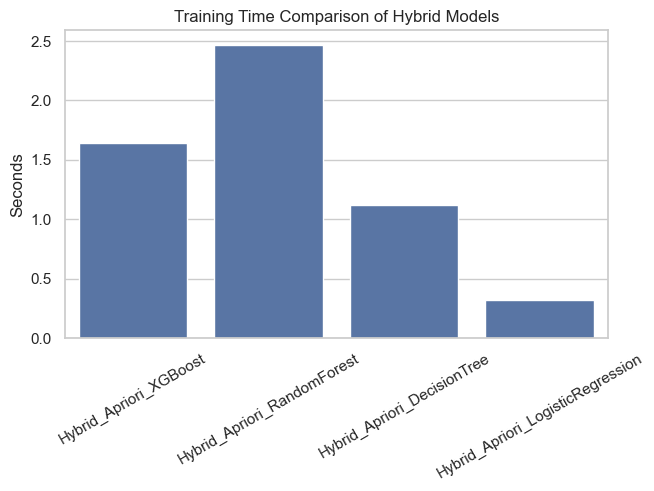

In [31]:
times = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    times[name] = end - start

plt.figure(figsize=(7,4))
sns.barplot(x=list(times.keys()), y=list(times.values()))
plt.title("Training Time Comparison of Hybrid Models")
plt.ylabel("Seconds")
plt.xticks(rotation=30)
plt.show()


### 8️⃣ Support vs Confidence vs Lift (Apriori Rules)

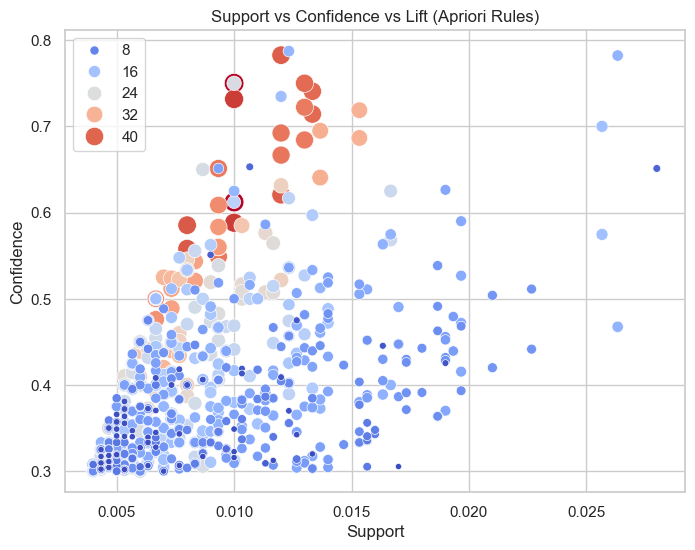

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="support", y="confidence", size="lift", data=rules, hue="lift", palette="coolwarm", sizes=(20,200))
plt.title("Support vs Confidence vs Lift (Apriori Rules)")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.legend()
plt.show()
